# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [14]:
path = "D:/Dicoding/Machine Learning/Submission/hasil_clustering.csv"
df = pd.read_csv(path)

df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23,1
1,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23,1
2,ORD3,CUS1806,B2B,Tomato Juice,Juices,2.14,44,0.10,84.74,Hamburg,2022-11-20,1
3,ORD3,CUS1806,B2B,Vittel,Water,0.43,13,0.05,5.31,Hamburg,2022-11-20,1
4,ORD3,CUS1806,B2B,Evian,Water,1.38,3,0.05,3.93,Hamburg,2022-11-20,1


In [15]:
df.tail()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
37818,ORD16765,CUS6053,B2C,Cranberry Juice,Juices,3.67,2,0.0,7.34,Hessen,2023-06-15,1
37819,ORD16765,CUS6053,B2C,Passion Fruit Juice,Juices,3.11,12,0.0,37.32,Hessen,2023-06-15,1
37820,ORD16765,CUS6053,B2C,Apollinaris,Water,0.99,8,0.0,7.92,Hessen,2023-06-15,1
37821,ORD16766,CUS1880,B2C,Riesling,Alcoholic Beverages,4.07,11,0.0,44.77,Rheinland-Pfalz,2021-05-12,0
37822,ORD16766,CUS1880,B2C,Selters,Water,0.46,9,0.0,4.14,Rheinland-Pfalz,2021-05-12,0


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [16]:
df = df.drop(columns=['Order_Date'])

In [17]:
# Buat instance LabelEncoder
label_encoder = LabelEncoder()
 
# List kolom kategorikal yang perlu di-encode
categorical_columns = ['Order_ID', 'Customer_ID', 'Customer_Type', 'Product', 'Category', 'Region']
 
# Encode kolom kategorikal
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])
 
# Tampilkan DataFrame untuk memastikan encoding telah diterapkan
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Cluster
0,0,438,0,35,3,1.66,53,0.10,79.18,0,1
1,0,438,0,11,3,0.87,35,0.10,27.40,0,1
2,8273,714,0,34,1,2.14,44,0.10,84.74,5,1
3,8273,714,0,36,3,0.43,13,0.05,5.31,5,1
4,8273,714,0,8,3,1.38,3,0.05,3.93,5,1


In [18]:
# Buat instance MinMaxScaler
scaler = MinMaxScaler()
 
# Normalisasi semua kolom numerik
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
 
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['Cluster'])
y = df['Cluster']
 
# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(30258, 10), y_train=(30258,)
Test set shape: X_test=(7565, 10), y_test=(7565,)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [19]:
# Bagian 1: Pelatihan Model
knn = KNeighborsClassifier().fit(X_train, y_train)

# Prediksi menggunakan data uji
y_pred = knn.predict(X_test)

print("Model training selesai.")

Model training selesai.


## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [20]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results = {
        'Confusion Matrix': cm,
        'True Positive (TP)': tp,
        'False Positive (FP)': fp,
        'False Negative (FN)': fn,
        'True Negative (TN)': tn,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    return results
 
# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test)
}
 
# Buat DataFrame untuk meringkas hasil
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
 
# Isi DataFrame dengan hasil
rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })
 
# Konversi daftar kamus ke DataFrame
summary_df = pd.DataFrame(rows)
 
# Tampilkan DataFrame
print(summary_df)

                       Model  Accuracy  Precision    Recall  F1-Score
0  K-Nearest Neighbors (KNN)  0.712624   0.720021  0.720391  0.720206


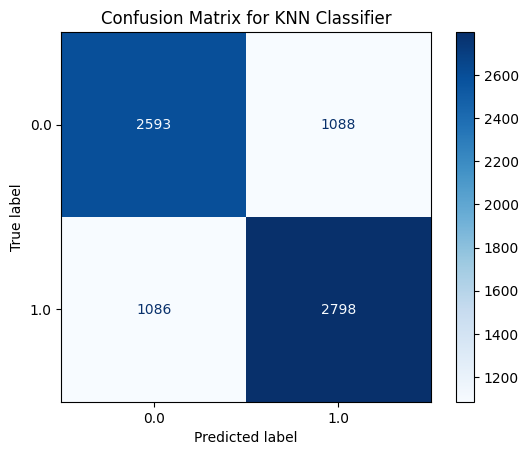

In [21]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title('Confusion Matrix for KNN Classifier')
plt.show()

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [22]:
#Type your code here

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [23]:
#Type your code here

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

In [24]:
from sklearn.metrics import accuracy_score

# Prediksi menggunakan data pelatihan
y_train_pred = knn.predict(X_train)

# Menghitung akurasi pada data pelatihan dan data uji
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi pada data pelatihan: {train_accuracy}")
print(f"Akurasi pada data uji: {test_accuracy}")


Akurasi pada data pelatihan: 0.8405710886377157
Akurasi pada data uji: 0.7126239259748843


### Analisa Hasil Klasifikasi
K-Nearest Neighbors (KNN) menunjukkan akurasi sebesar 71.26%. Model ini memiliki precision 72.00%, recall 72.04%, dan F1-Score 72.02%. Secara keseluruhan, model KNN menunjukkan kinerja yang cukup baik.

### Kesimpulan akhir
Model KNN memiliki performa yang cukup baik dengan keseimbangan antara precision dan recall. Namun, jika ingin meningkatkan akurasi dan kemampuan deteksi, kamu bisa mempertimbangkan tuning hyperparameter, pemilihan fitur yang lebih baik, atau mencoba model lain yang lebih kompleks seperti Random Forest atau XGBoost.

### Rekomendasi
- Melakukan cross-validation untuk memastikan model tidak overfitting.
- Memastikan data pelatihan representatif dan seimbang.
- Menggunakan teknik yang lebih canggih seperti Random Forest atau Gradient Boosting jika diperlukan.
- Memeriksa dan memilih fitur dengan hati-hati menggunakan teknik seperti feature selection atau feature engineering.